In [4]:
import pandas as pd
from datetime import datetime, timedelta, timezone
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import itertools
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

df = pd.read_csv("df.csv")
df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)

In [2]:
df.columns

Index(['Unnamed: 0', 'open', 'high', 'low', 'close', 'volume', 'log_return',
       'proxy_realised_variance', 'proxy_realised_volatility',
       'realized_variance', 'realized_volatility', 'fng',
       'value_classification', 'fng_change', 'google_trend', 'gtrend_change',
       'gtrend_pct_change', 'gold_close', 'gold_vol', 'silver_close',
       'silver_vol', 'brent_close', 'brent_vol', 'dji_close', 'dji_vol',
       'spx_close', 'spx_vol', 'rut_close', 'rut_vol', 'nasdaq_close',
       'nasdaq_vol', 'usdcny_close', 'usdeur_close', 'vix_close', 'hash-rate',
       'difficulty', 'median-confirmation-time',
       'blockchain_log_n_transactions', 'blockchain_log_transaction_fee_usd',
       'blockchain_log_n_unique_addresses', 'blockchain_log_mempool_count',
       'blockchain_log_transaction_volume+usd',
       'blockchain_diff_log_n_transactions',
       'blockchain_diff_log_transaction_fee_usd',
       'blockchain_diff_log_n_unique_addresses',
       'blockchain_diff_log_transact

In [5]:
# --- 1. SETTINGS & RANGES ---
total_len = len(df)
test_size = int(total_len * 0.15)
val_size = int(total_len * 0.15)

val_start = total_len - test_size - val_size
val_end = total_len - test_size

val_sample_indices = range(val_start, val_end, 10) 
window_size = 365 

p_values = [1, 2]
dist_values = ['t', 'skewt']
grid_results = []

# --- 2. TOURNAMENT PHASE ---
print(f"Tournament Phase: Testing {len(val_sample_indices)} samples...")

for p in p_values:
    for d in dist_values:
        errors = []
        for i in val_sample_indices:
            train_win = df.iloc[i - window_size : i]['log_return'] * 100
            target_val = df.iloc[i]['target']
            
            try:
                model = arch_model(train_win, vol='EGARCH', p=p, q=1, dist=d, rescale=False)
                res = model.fit(disp='off', show_warning=False)
                
                pred_vol_pct = np.sqrt(max(0, res.forecast(horizon=1).variance.values[-1, 0]))
                pred_vol_raw = pred_vol_pct / 100
                
                # --- SAFETY BRAKE ---
                pred_vol_raw = np.clip(pred_vol_raw, 0, 0.5)
                
                errors.append((target_val - pred_vol_raw)**2)
            except:
                errors.append(1.0)
        
        grid_results.append({
            'Model': f'EGARCH({p},1)', 'Dist': d, 'Val_RMSE': np.sqrt(np.mean(errors))
        })

leaderboard = pd.DataFrame(grid_results).sort_values('Val_RMSE')
print(leaderboard)
winner = leaderboard.iloc[0]
print(f"\nWINNER: {winner['Model']} with {winner['Dist']} distribution")
best_model_name = winner['Model']
best_dist = winner['Dist']

p_match = re.search(r'\((\d+),(\d+)\)', best_model_name)
best_p = int(p_match.group(1))
best_q = int(p_match.group(2))

Tournament Phase: Testing 55 samples...
         Model   Dist  Val_RMSE
0  EGARCH(1,1)      t  0.020161
1  EGARCH(1,1)  skewt  0.067371
3  EGARCH(2,1)  skewt  0.157466
2  EGARCH(2,1)      t  0.165979

WINNER: EGARCH(1,1) with t distribution


In [6]:
# --- 3. FULL VALIDATION PHASE ---
full_val_indices = range(val_start, val_end)
final_preds = []
actuals = []

# Counters for your report
explosions = 0
failures = 0

print(f"Running full validation on all {len(full_val_indices)} days...")

for i in full_val_indices:
    train_win = df.iloc[i - window_size : i]['log_return'] * 100
    target_val = df.iloc[i]['target']
    
    try:
        model = arch_model(train_win, vol='EGARCH', p=best_p, q=best_q, dist=best_dist, rescale=False)
        res = model.fit(disp='off', show_warning=False)
        
        pred_variance_pct = res.forecast(horizon=1).variance.values[-1, 0]
        pred_vol_raw = np.sqrt(max(0, pred_variance_pct)) / 100
        
        # --- DETECT AND CAP ---
        if pred_vol_raw > 0.5 or np.isinf(pred_vol_raw):
            explosions += 1
            pred_vol_raw = 0.5
            
        final_preds.append(pred_vol_raw)
        actuals.append(target_val)
        
    except Exception as e:
        failures += 1
        val = final_preds[-1] if final_preds else 0.02
        final_preds.append(val)
        actuals.append(target_val)

# --- 4. RESULTS & METRICS ---
actuals = np.array(actuals)
final_preds = np.array(final_preds)

rmse = np.sqrt(np.mean((actuals - final_preds)**2))
mae = np.mean(np.abs(actuals - final_preds))

print(f"\n--- FINAL VALIDATION SCORES ---")
print(f"Model: {best_model_name} | Dist: {best_dist}")
print(f"Validation RMSE: {rmse:.6f}")
print(f"Validation MAE:  {mae:.6f}")
print(f"Explosions: {explosions} | Crashes: {failures}")

Running full validation on all 548 days...

--- FINAL VALIDATION SCORES ---
Model: EGARCH(1,1) | Dist: t
Validation RMSE: 0.047646
Validation MAE:  0.022380
Explosions: 4 | Crashes: 0


In [45]:
# --- 1. DEFINE CATEGORIES (The "Buckets") ---
# Based on your column list, we group relevant variables

feature_groups = {
    'Core Price Action & Returns': [
        'open', 'high', 'low', 'close', 'log_return'
    ],
    'Internal Volatility Proxies': [
        'proxy_realised_variance', 'proxy_realised_volatility',
        'realized_variance', 'realized_volatility', 
        'RV_1', 'RV_7', 'RV_30', 'target'
    ],
    'Sentiment & Attention': [
        'fng', 'value_classification', 'fng_change', 
        'google_trend', 'gtrend_change', 'gtrend_pct_change'
    ],
    'Trad-Fi & Macro (Prices & Vol)': [
        'gold_close', 'gold_vol', 'silver_close', 'silver_vol', 
        'brent_close', 'brent_vol', 'dji_close', 'dji_vol', 
        'spx_close', 'spx_vol', 'rut_close', 'rut_vol', 
        'nasdaq_close', 'nasdaq_vol', 'vix_close',
        'usdcny_close', 'usdeur_close'
    ],
    'Blockchain Health (Mining)': [
        'hash-rate', 'difficulty', 'median-confirmation-time'
    ],
    'Blockchain Flows (Network Activity)': [
        'blockchain_log_n_transactions', 'blockchain_log_transaction_fee_usd',
        'blockchain_log_n_unique_addresses', 'blockchain_log_mempool_count',
        'blockchain_log_transaction_volume+usd',
        'blockchain_diff_log_n_transactions',
        'blockchain_diff_log_transaction_fee_usd',
        'blockchain_diff_log_n_unique_addresses',
        'blockchain_diff_log_transaction_volume_usd'
    ],
    'Volume & Trading Metadata': [
        'volume', 'log_volume', 'Unnamed: 0'
    ]
}


# flatten the list to get all columns of interest for the heatmap
all_selected_cols = [col for group in feature_groups.values() for col in group]

# Ensure they exist in your df
available_cols = [c for c in all_selected_cols if c in df.columns]
corr_df = df[available_cols].copy()

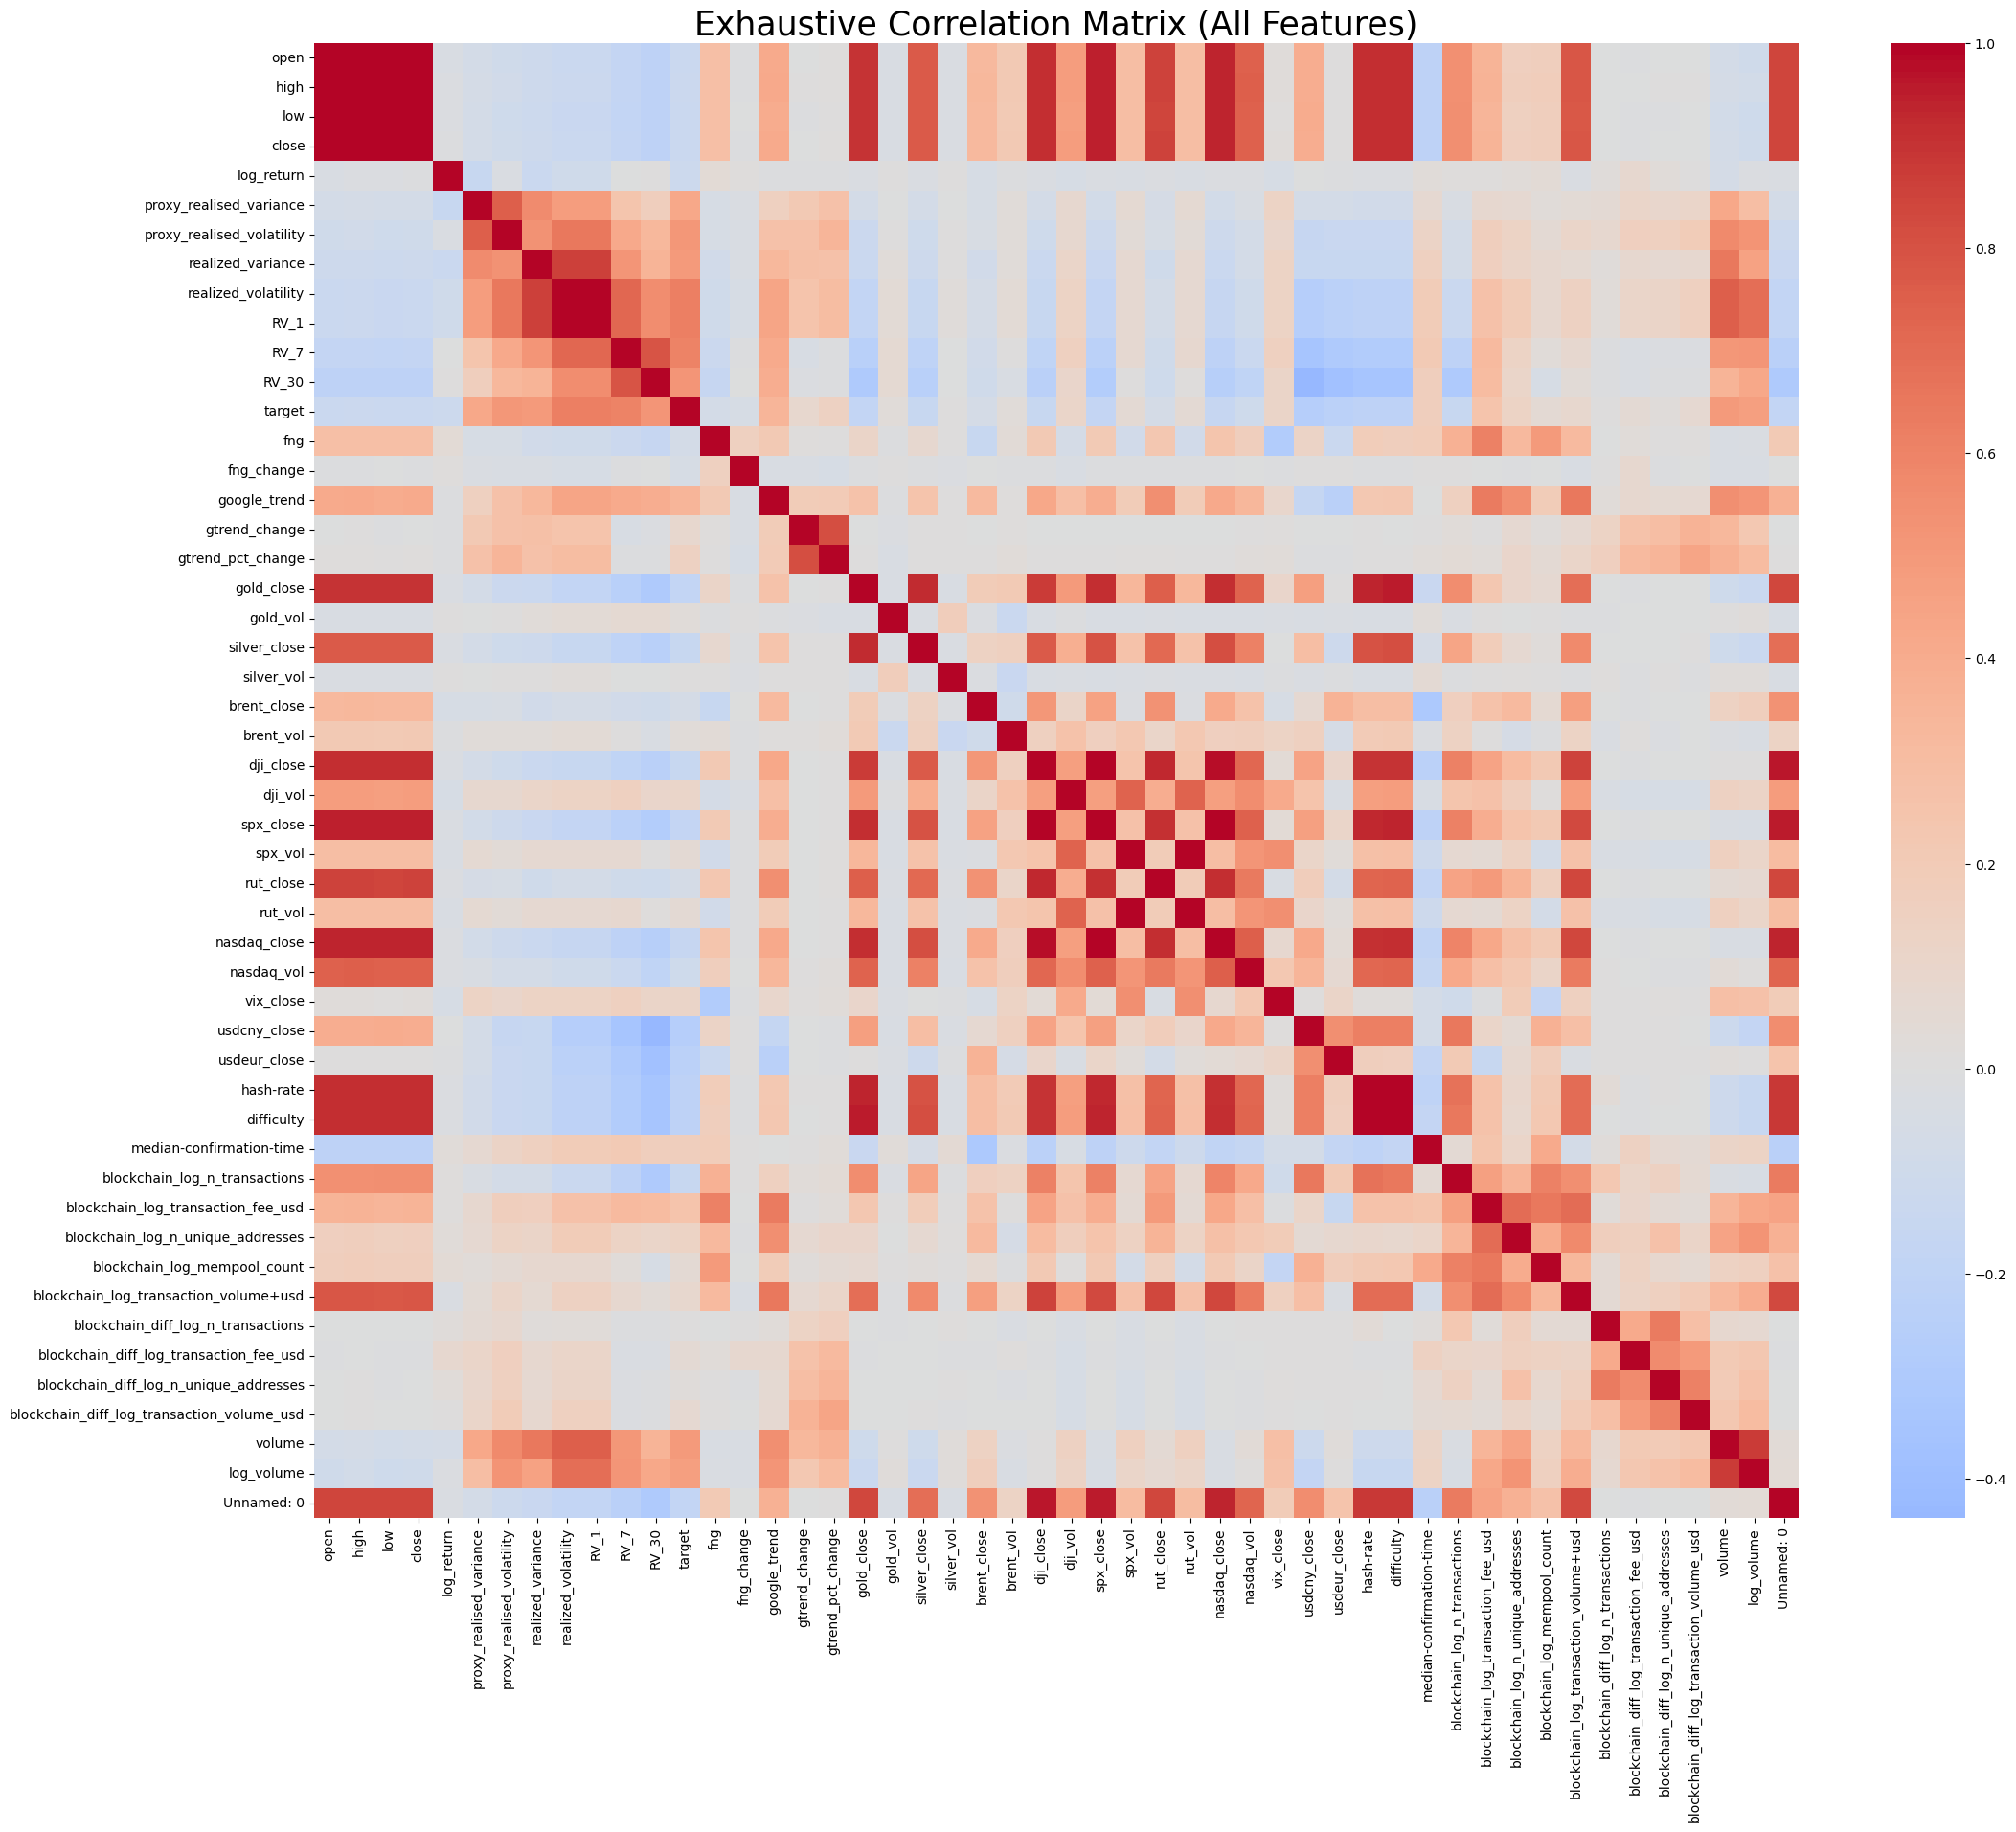

In [46]:

# --- 2. THE TOTAL HEATMAP CODE ---
# Flatten all lists to ensure we catch every single name
all_cols = [col for group in feature_groups.values() for col in group]

# Filter for only numeric columns that actually exist in your DF
plot_df = df[all_cols].select_dtypes(include=[np.number])

plt.figure(figsize=(25, 20))
sns.heatmap(plot_df.corr(), cmap='coolwarm', annot=False, center=0)
plt.title("Exhaustive Correlation Matrix (All Features)", fontsize=25)
plt.savefig('full_feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()